# 📊 Étape 1b — Analyse Visuelle (EDA)
## Système de Prédiction des Fraudes — Assurance Automobile
**Auteur :** BENKHOUD Mohamed Bayrem  
---

### Objectif
Cette étape consiste à explorer visuellement le dataset pour valider nos hypothèses métiers et identifier les signaux faibles de fraude.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration du style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Bibliothèques prêtes')

✅ Bibliothèques prêtes


## 1. Chargement et Préparation des Données

In [6]:
import pandas as pd
import numpy as np

# Chemin du fichier
file_path = r'C:\Users\bayre\OneDrive\Bureau\projet ML\data\insurance_claims.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    
    # Remplacement des '?' par des NaN pour un traitement propre
    df = df.replace('?', np.nan)
    
    # Conversion des dates et calcul du délai
    df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'], errors='coerce')
    df['incident_date'] = pd.to_datetime(df['incident_date'], errors='coerce')
    
    # On s'assure que les colonnes de date existent avant de calculer
    if 'incident_date' in df.columns and 'policy_bind_date' in df.columns:
        df['claim_delay_days'] = (df['incident_date'] - df['policy_bind_date']).dt.days
    
    print(f'✅ Dataset chargé avec succès : {df.shape[0]} lignes')
else:
    print(f'❌ Fichier introuvable au chemin : {file_path}')

✅ Dataset chargé avec succès : 1000 lignes


### 🔎 Analyse 1 : Distribution de la Cible (Fraude)

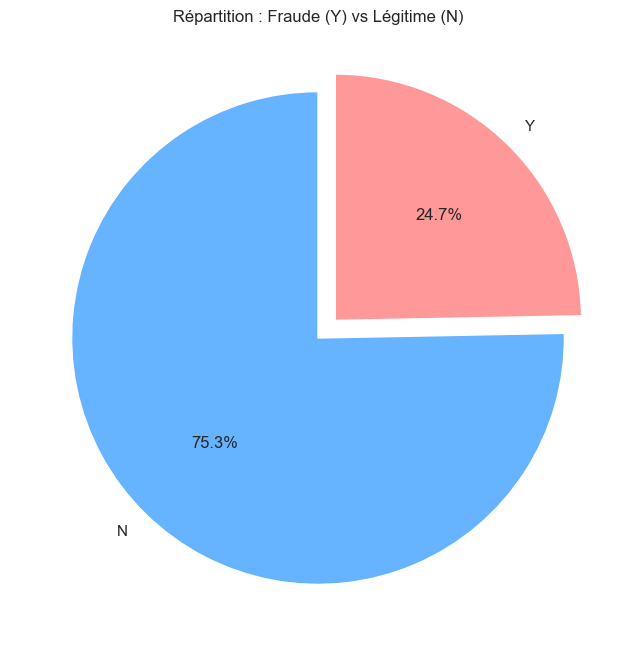

In [7]:
import matplotlib.pyplot as plt

if 'df' in locals():
    plt.figure(figsize=(8, 8))
    counts = df['fraud_reported'].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', 
            colors=['#66b3ff','#ff9999'], explode=(0, 0.1), startangle=90)
    plt.title('Répartition : Fraude (Y) vs Légitime (N)')
    plt.show()
else:
    print("⚠️ Chargez d'abord le dataset dans la cellule précédente.")

### 🔎 Analyse 2 : Gravité de l'Incident vs Fraude

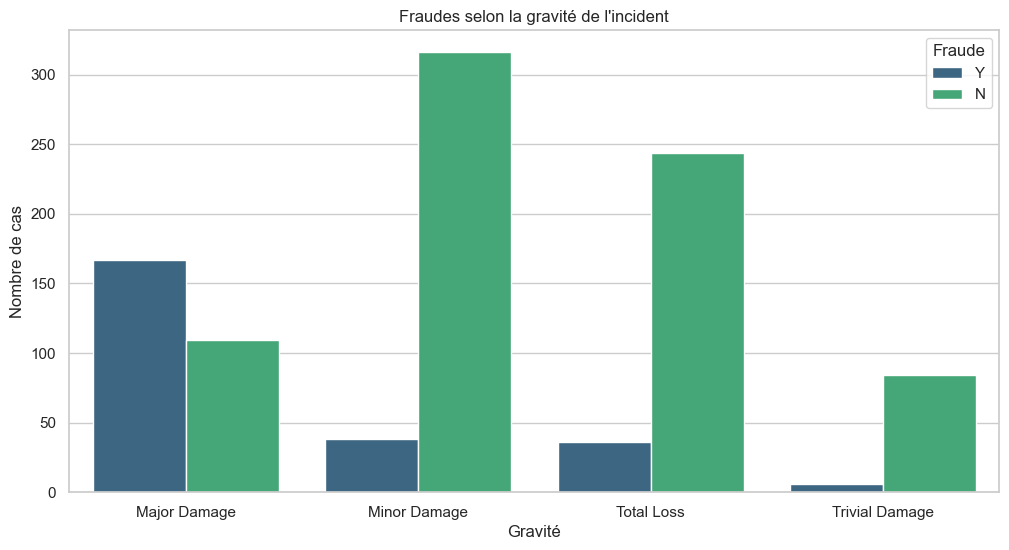

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'df' in locals():
    sns.countplot(data=df, x='incident_severity', hue='fraud_reported', palette='viridis')
    plt.title('Fraudes selon la gravité de l\'incident')
    plt.xlabel('Gravité')
    plt.ylabel('Nombre de cas')
    plt.legend(title='Fraude')
    plt.show()
else:
    print("⚠️ Chargez d'abord le dataset.")

### 🔎 Analyse 3 : Distribution des Montants Réclamés

C:\Users\bayre\AppData\Local\Temp\ipykernel_10932\4113527218.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='fraud_reported', y='total_claim_amount', palette='Set2')


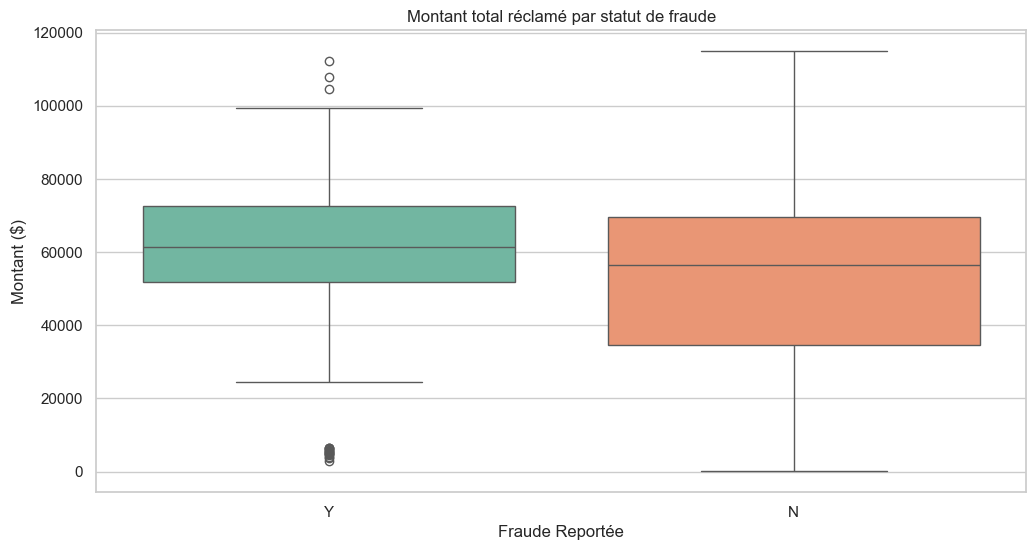

In [9]:
if 'df' in locals():
    sns.boxplot(data=df, x='fraud_reported', y='total_claim_amount', palette='Set2')
    plt.title('Montant total réclamé par statut de fraude')
    plt.xlabel('Fraude Reportée')
    plt.ylabel('Montant ($)')
    plt.show()

### 🔎 Analyse 4 : Matrice de Corrélation

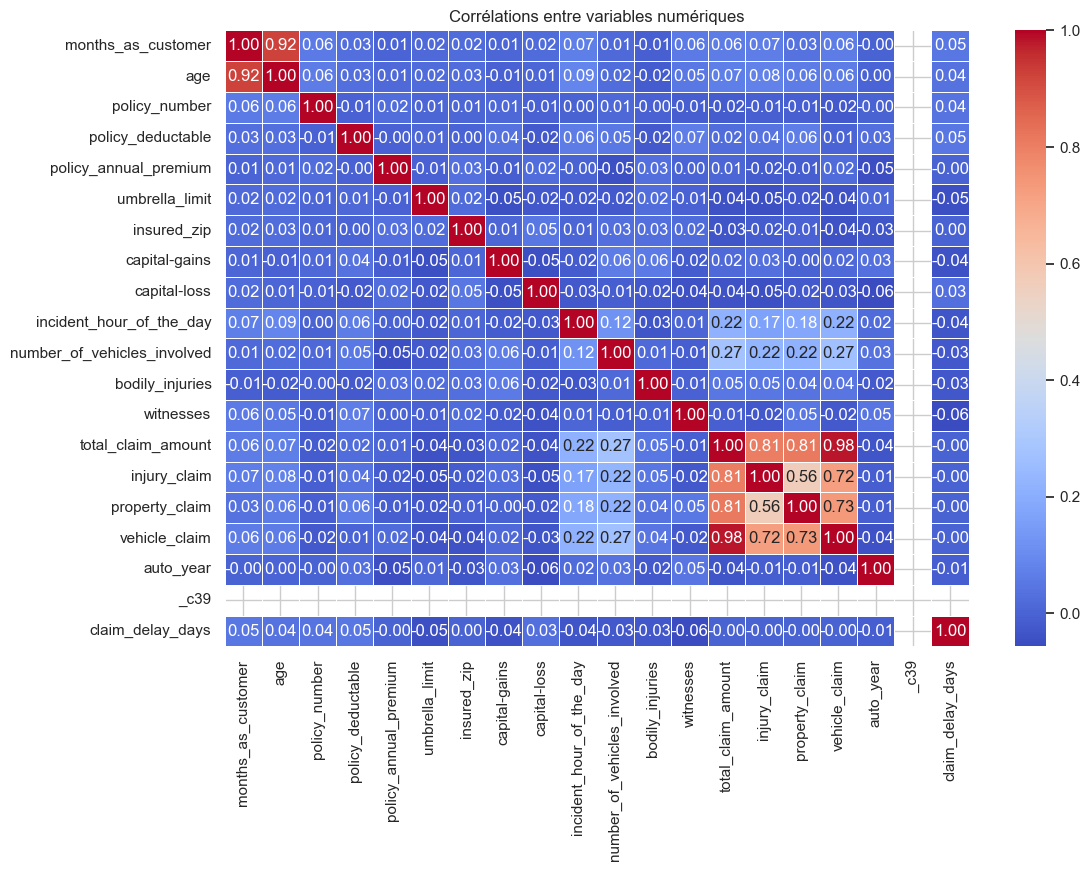

In [10]:
if 'df' in locals():
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Corrélations entre variables numériques')
    plt.show()

### 🔎 Analyse 5 : Top Hobbies des Fraudeurs

C:\Users\bayre\AppData\Local\Temp\ipykernel_10932\3632959340.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_rate.index, y=fraud_rate.values, palette='magma')


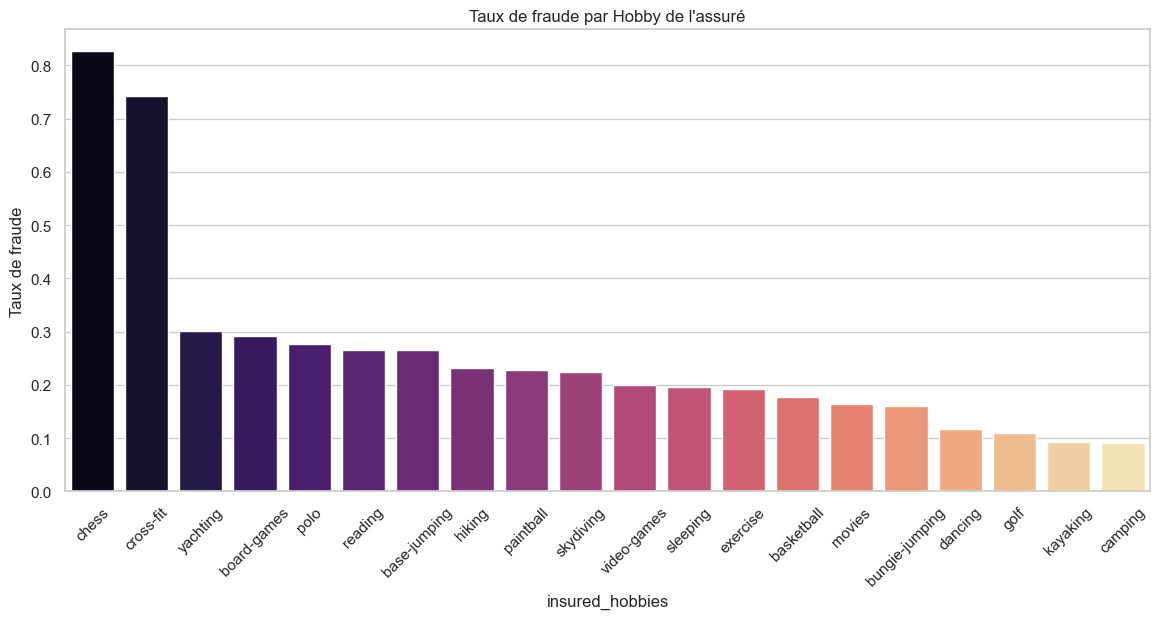

In [11]:
if 'df' in locals():
    # Calcul du taux de fraude par hobby
    h_fraud = df[df['fraud_reported'] == 'Y']['insured_hobbies'].value_counts()
    h_total = df['insured_hobbies'].value_counts()
    fraud_rate = (h_fraud / h_total).sort_values(ascending=False)

    plt.figure(figsize=(14, 6))
    sns.barplot(x=fraud_rate.index, y=fraud_rate.values, palette='magma')
    plt.xticks(rotation=45)
    plt.title('Taux de fraude par Hobby de l\'assuré')
    plt.ylabel('Taux de fraude')
    plt.show()

## Conclusion de l'Analyse
La fraude semble fortement liée à la **gravité de l'incident** et à certains profils spécifiques (Loisirs). Le montant total réclamé est un indicateur important mais pas unique.